# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

df = pd.read_csv('premier_league_complete_stats_2025-26.csv', encoding=
                 'latin1')

df.head()

,player_name,team_name,position,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,...,totalDuelsWonPercentage,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,Declan Rice,Arsenal,M,41,28.082192,459,72,48.648649,891,687,...,61.111111,148,1054,743,1797,36,3,2327,8,2
1,Gabriel Magalhães,Arsenal,D,1,20.000000,180,63,46.323529,512,747,...,70.334928,136,622,797,1419,18,5,1747,27,3
2,Bukayo Saka,Arsenal,F,36,32.432432,300,14,36.842105,419,105,...,53.020134,38,557,126,683,63,4,1236,51,1
3,Martín Zubimendi,Arsenal,M,2,18.181818,369,48,49.484536,833,661,...,60.189573,97,985,709,1694,26,2,2026,10,4
4,Max Dowman,Arsenal,M,0,0.000000,9,0,0.000000,13,3,...,42.857143,0,14,3,17,5,0,51,4,0


The dataset I picked is data of all football players in the premier league this seasons 2025-26. Recorded is their statistcis suchs as number of appearances, touches, duels won, and etc. My main target is going be the player's assist record this season. using other feature to help visualize the relationship between and how it affects the value for assists.

In [5]:
list(df.columns)

['player_name',
 'team_name',
 'position',
 'accurateCrosses',
 'accurateCrossesPercentage',
 'accurateFinalThirdPasses',
 'accurateLongBalls',
 'accurateLongBallsPercentage',
 'accurateOppositionHalfPasses',
 'accurateOwnHalfPasses',
 'accuratePasses',
 'accuratePassesPercentage',
 'aerialDuelsWon',
 'aerialDuelsWonPercentage',
 'aerialLost',
 'appearances',
 'assists',
 'ballRecovery',
 'bigChancesCreated',
 'bigChancesMissed',
 'blockedShots',
 'cleanSheet',
 'clearances',
 'dispossessed',
 'dribbledPast',
 'duelLost',
 'errorLeadToGoal',
 'errorLeadToShot',
 'expectedAssists',
 'expectedGoals',
 'fouls',
 'freeKickGoal',
 'goalConversionPercentage',
 'goals',
 'goalsAssistsSum',
 'goalsConceded',
 'goalsConcededInsideTheBox',
 'goalsConcededOutsideTheBox',
 'goalsFromInsideTheBox',
 'goalsFromOutsideTheBox',
 'goalsPrevented',
 'groundDuelsWon',
 'groundDuelsWonPercentage',
 'headedGoals',
 'highClaims',
 'hitWoodwork',
 'inaccuratePasses',
 'interceptions',
 'keyPasses',
 'leftFoo

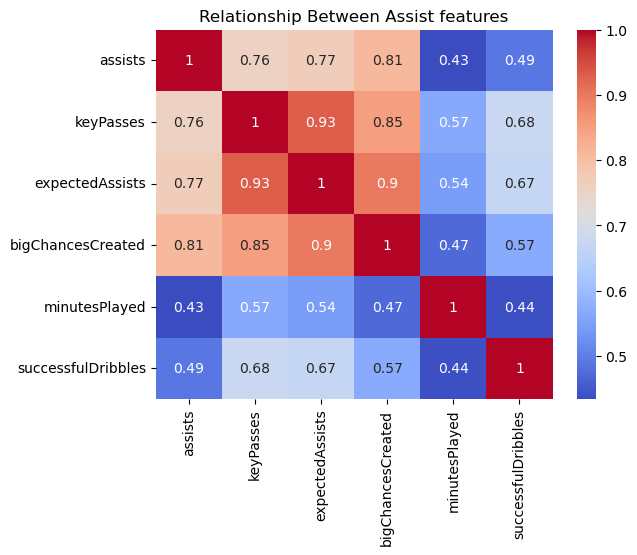

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['assists', 'keyPasses', 'expectedAssists', 'bigChancesCreated', 'minutesPlayed', 'successfulDribbles']

corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Relationship Between Assist features')
plt.show()

This map tells me that for a higher and successful conversion of assists, the player's big chances created, key passes, and expected assists take high priority. The player's sucessful dribbles and minutes played does apply moderately towards the value of the assists. 

In [24]:
import plotly.express as px

df['player_position'] = df['position'].astype(str).str.strip()
player_info = ['team_name', 
               'keyPasses', 
               'bigChancesCreated', 
               'totalAttemptAssist', 
               'successfulDribbles', 
               'minutesPlayed']

fig = px.scatter(
    df,
    x= 'expectedAssists',
    y= 'assists',
    size = 'minutesPlayed',
    hover_name = 'player_name',
    hover_data= player_info,
    title = 'Expected Assists'
)
fig.show()

Here we have a ploto of all footballers ranging in positions and thier contributions. It is clear that we one exceptional footballer who has the most assists amongst all. The player Bruno Fernandes has recorded a staggering 16 assist surpassing his expected assists. He has recorded the high number in key passes (101) and attempted assists (101). I can concluded that the number of key passes a player registers influence in the value for assists. Minutes player contributes less and is seen as some players managed to register above 1000+ mintues played yet it doesn't entirely help them conver more assists. As seen by players like Mathias Jense and Yeremy Pino only having 1 assist and more than 1000 minutes play. Features like sucessful dribbles don't seem to influence alot, I can many players recorded 30+ dribbles and ended up with less than 4 asissts while those shy from 20 dribbles recording more assists. A good example is Bruno Fernandes once again with 15 dribbles and 16 assists. 